In [1]:
import os
import random
from PIL import Image
import cv2
import tifffile as tiff
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

In [2]:
dataset_path = '/kaggle/input/datasets/saharamrr/satalitedataset/data'
dataset_dir = os.listdir(dataset_path)
print(f'the data contains {dataset_dir}')

the data contains ['labels', 'images']


In [3]:
image_dir = dataset_path + '/images'
image_paths = sorted(glob(os.path.join(image_dir, "*.tif")))
images = [tiff.imread(image_path) for image_path in image_paths]

In [4]:
mask_dir = dataset_path + '/labels'
mask_paths = sorted(glob(os.path.join(mask_dir, '*.png')))
masks = [cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in mask_paths]
print(f'Masks loaded: {len(masks)}')


Masks loaded: 456


# **Check File Names**

In [5]:
import glob
import tifffile as tiff

image_dir = os.path.join(dataset_path, 'images')
mask_dir = os.path.join(dataset_path, 'labels')

# Get the list of file paths first
# Using glob to find all files with specific extensions
image_paths = sorted(glob.glob(os.path.join(image_dir, "*.tif")))
mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*.png"))) # Or *.tif depending on your labels

# Load the actual data into lists
# Note: For satellite TIFs, ensure you have 'tifffile' or use 'rasterio'
images = [tiff.imread(p) for p in image_paths]
masks = [cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in mask_paths]


print("Images found:", len(image_paths))
print("Labels found:", len(mask_paths))

if len(images) > 0:
    print(f"Sample Image Shape: {images[0].shape}")
    print(f"Sample Mask Shape: {masks[0].shape}")

Images found: 306
Labels found: 456
Sample Image Shape: (128, 128, 12)
Sample Mask Shape: (128, 128)


In [6]:
image_names = set([os.path.splitext(os.path.basename(f))[0] for f in image_paths])
label_names = set([os.path.splitext(os.path.basename(f))[0] for f in mask_paths])

print("Images without labels:", len(image_names - label_names))
print("Labels without images:", len(label_names - image_names))

Images without labels: 0
Labels without images: 150


In [7]:
common_names = sorted(list(image_names & label_names))
print("Total valid pairs:", len(common_names))

Total valid pairs: 306


# **STEP 1: Data Alignment (Pairing Images with Labels)**

## What is Data Alignment?
- **Satellite Dataset Structure**: TIF files (images) and PNG files (ground truth labels)
- **Goal**: Ensure each satellite image has a matching label
- **Action**: Find common filenames between folders
- **Why**: Missing pairs cause training errors

In [8]:
# 3. Rebuild clean path lists using the common names
# We use os.path.join to ensure the paths are correct for your environment
clean_image_paths = [os.path.join(image_dir, name + ".tif") for name in common_names]
clean_label_paths = [os.path.join(mask_dir, name + ".png") for name in common_names]

print("Clean images list size:", len(clean_image_paths))
print("Clean labels list size:", len(clean_label_paths))

Clean images list size: 306
Clean labels list size: 306


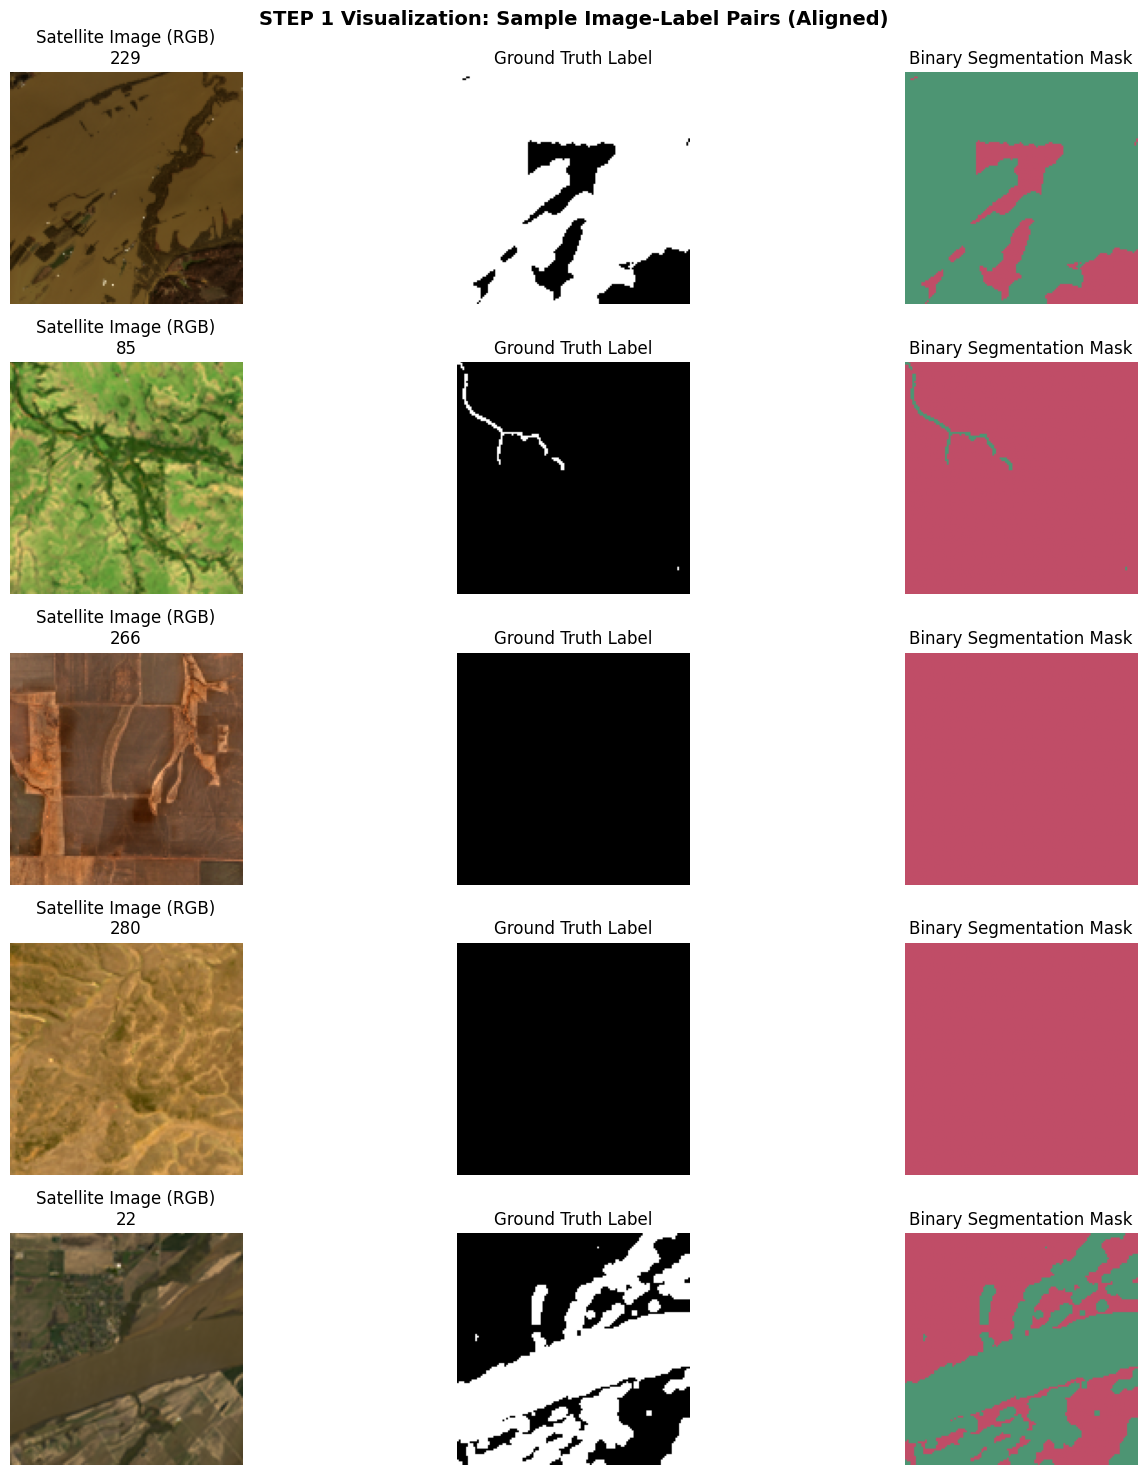

In [9]:
# Show 5 random matched pairs
import random
sample_indices = random.sample(range(len(common_names)), min(5, len(common_names)))

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(15, 3*len(sample_indices)))
fig.suptitle('STEP 1 Visualization: Sample Image-Label Pairs (Aligned)', fontsize=14, fontweight='bold')

for row, idx in enumerate(sample_indices):
    name = common_names[idx]
    img_path = os.path.join(image_dir, name + ".tif")
    label_path = os.path.join(mask_dir, name + ".png")
    
    # Load image (use RGB bands: R=Red, G=Green, B=Blue)
    img = tiff.imread(img_path)
    rgb_img = np.stack([img[:,:,3], img[:,:,2], img[:,:,1]], axis=-1)  # R,G,B bands
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())  # Normalize for display
    
    # Load label
    label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
    
    # Plot
    axes[row, 0].imshow(rgb_img)
    axes[row, 0].set_title(f'Satellite Image (RGB)\n{name}')
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(label, cmap='gray')
    axes[row, 1].set_title(f'Ground Truth Label')
    axes[row, 1].axis('off')
    
    # Binary mask
    axes[row, 2].imshow(label > 0, cmap='RdYlGn', alpha=0.7)
    axes[row, 2].set_title(f'Binary Segmentation Mask')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('step1_data_alignment.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
clean_image_files = [name + ".tif" for name in common_names]
clean_label_files = [name + ".png" for name in common_names]

print("Clean images:", len(clean_image_files))
print("Clean labels:", len(clean_label_files))

Clean images: 306
Clean labels: 306


# **STEP 2: Band-Wise Normalization**

- **Raw TIF values**: Often 0 to 10,000+ (different range for each band)
- **After normalization**: All bands scaled to [0, 1]
- **Method**: Min-Max scaling: (x - min) / (max - min)

In [11]:
def minmax_normalize(image):
    """
    Normalizes a multi-band image. 
    Assumes image shape is (H, W, C) or (C, H, W).
    """
    image = image.astype(np.float32)
    normalized = np.zeros_like(image, dtype=np.float32)
    
    # Check if bands are first (C, H, W) or last (H, W, C)
    # Your notebook shows 'Bands: 12' as the first dimension
    if image.shape[0] == 12: # Bands-first format
        for i in range(image.shape[0]):
            band = image[i, :, :]
            min_val, max_val = band.min(), band.max()
            if max_val - min_val != 0:
                normalized[i, :, :] = (band - min_val) / (max_val - min_val)
            else:
                normalized[i, :, :] = band
    else: # Channels-last format
        for i in range(image.shape[-1]):
            band = image[:, :, i]
            min_val, max_val = band.min(), band.max()
            if max_val - min_val != 0:
                normalized[:, :, i] = (band - min_val) / (max_val - min_val)
            else:
                normalized[:, :, i] = band
                
    return normalized

In [12]:
# Apply normalization to ALL images in the dataset
images_norm = []
for i, path in enumerate(clean_image_paths):
    img = tiff.imread(path)
    images_norm.append(minmax_normalize(img))

# Also reload ALL matched masks (using clean_label_paths)
masks_all = [cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in clean_label_paths]


In [33]:
# Show normalization effect on a sample image (no plotting)
sample_idx = random.randint(0, len(images_norm) - 1)
sample_path = clean_image_paths[sample_idx]
sample_raw = tiff.imread(sample_path).astype(np.float32)
sample_normalized = images_norm[sample_idx]

# Determine number of bands (safe)
if sample_raw.ndim == 3:
    num_bands = sample_raw.shape[2]
elif sample_raw.ndim == 2:
    num_bands = 1
else:
    num_bands = sample_raw.shape[0]

print(f'Selected sample index: {sample_idx} - {os.path.basename(sample_path)} | num_bands={num_bands}')
# Optional: print per-band min/max before and after normalization
for b in range(num_bands):
    try:
        rmin, rmax = float(sample_raw[:,:,b].min()), float(sample_raw[:,:,b].max())
        nmin, nmax = float(sample_normalized[:,:,b].min()), float(sample_normalized[:,:,b].max())
    except Exception:
        pass


Selected sample index: 284 - 8.tif | num_bands=12


In [14]:
def visualize_image_bands(image, title='Image Bands'):
    num_bands = image.shape[-1]
    bands = ['Coastal aerosal', 'Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'QA Band'
             , 'Merit DEM', 'Copernicus DEM', 'ESA world cover map', 'Water occurence probability']
    fig, axes = plt.subplots(1, num_bands, figsize=(25, 3))
    fig.suptitle(title, fontsize=15)

    for i in range(num_bands):
        ax = axes[i] if num_bands > 1 else axes
        ax.imshow(image[:, :, i], cmap='gray')
        ax.set_title(f'Band {i + 1}\n{bands[i]}', fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

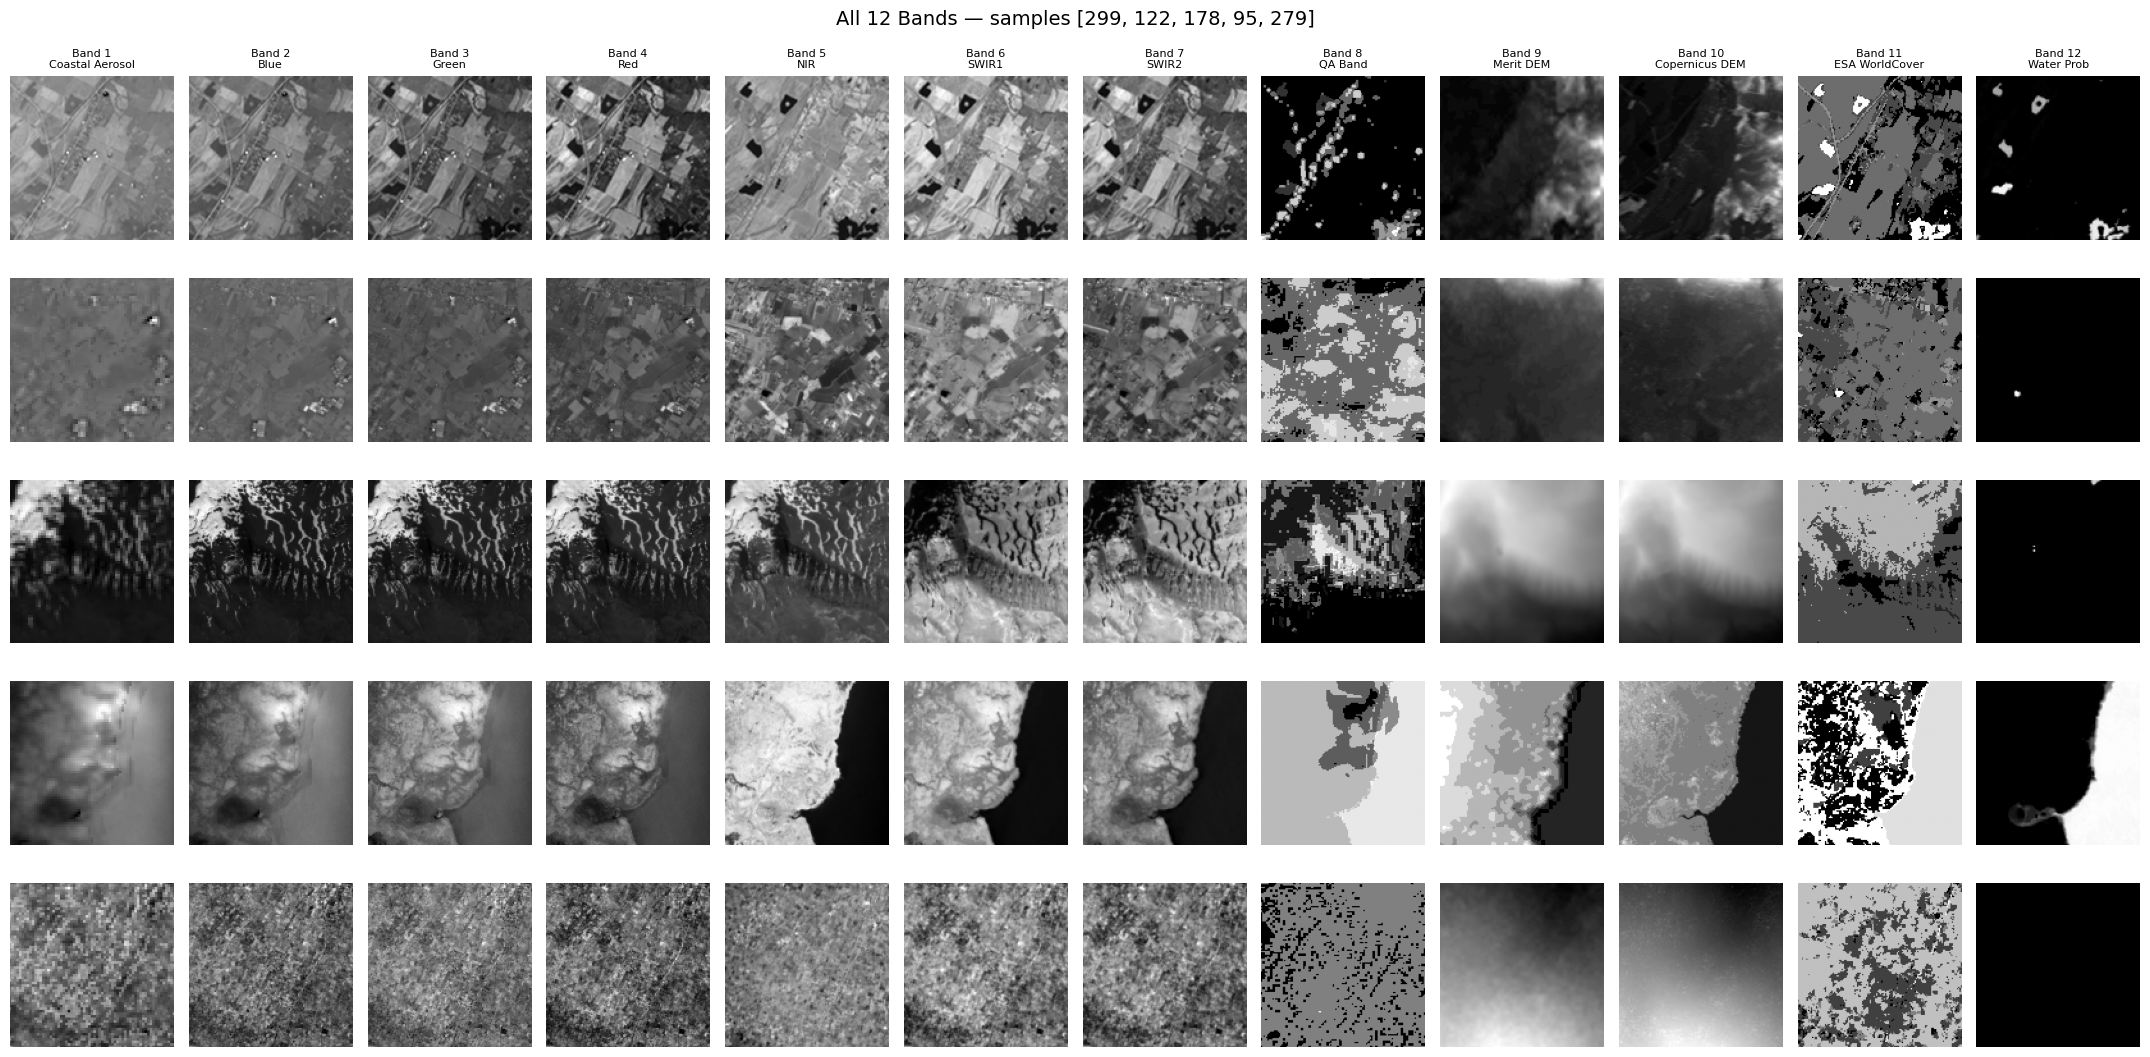

Showing sample indices: [299, 122, 178, 95, 279]


In [35]:
import random

band_names = ['Coastal Aerosol','Blue','Green','Red','NIR','SWIR1','SWIR2',
              'QA Band','Merit DEM','Copernicus DEM','ESA WorldCover','Water Prob']
num_bands = 12

# Pick five random samples and display all 12 bands for each (no colorbars)
n_samples = 5
sample_indices = random.sample(range(len(images_norm)), min(n_samples, len(images_norm)))

fig, axes = plt.subplots(len(sample_indices), num_bands, figsize=(num_bands*1.8, len(sample_indices)*2.2))
fig.suptitle(f'All 12 Bands — samples {sample_indices}', fontsize=14)

# Ensure 2D indexing for axes
if len(sample_indices) == 1:
    axes = axes[None, :]

for i, idx in enumerate(sample_indices):
    rep_img = images_norm[idx]
    rep_name = os.path.basename(clean_image_paths[idx])
    for b in range(num_bands):
        ax = axes[i, b]
        ax.imshow(rep_img[:, :, b], cmap='gray')
        ax.axis('off')
        if i == 0:
            ax.set_title(f'Band {b+1}\n{band_names[b]}', fontsize=8)
    # label the row with sample info
    axes[i, 0].set_ylabel(f'Sample {i+1}\n{rep_name}', fontsize=8)

plt.tight_layout()
plt.show()
print(f'Showing sample indices: {sample_indices}')


# **STEP 3 & 4: Model Construction & Training**

## U-Net Architecture Overview
```
INPUT (128×128×12)
    ↓
ENCODER (Contracting Path) - Captures Context
    Conv → Pool → Conv → Pool → Conv → Pool → Conv → Pool
    (64 filters) (128) (256) (512)
    ↓
BOTTLENECK (8×8×1024) - Deepest Feature Representation
    ↓
DECODER (Expanding Path) - Restores Details  
    UpSample ← Skip Connection → UpSample ← Skip Connection...
    (512) (256) (128) (64)
    ↓
OUTPUT (128×128×1) - Binary Segmentation Mask
```
- **Skip Connections**: Transfer fine details from encoder to decoder (sharp boundaries)
- **Dropout**: Prevents overfitting by randomly disabling neurons (20-40%)
- **L2 Regularization**: Penalizes large weights to avoid memorization

In [36]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

#  Train / Validation split (80 / 20) 
X_train_paths, X_val_paths, y_train_paths, y_val_paths = train_test_split(
    clean_image_paths, clean_label_paths, test_size=0.2, random_state=42
)
print(f'Train: {len(X_train_paths)}  |  Val: {len(X_val_paths)}')


#  Load one (image, mask) pair from disk 
def load_sample(img_path, mask_path):
    import tifffile as tiff, cv2, numpy as np
    img  = tiff.imread(img_path.numpy().decode())                # (H,W,12)
    mask = cv2.imread(mask_path.numpy().decode(), cv2.IMREAD_GRAYSCALE)
    img  = minmax_normalize(img).astype(np.float32)
    mask = (mask > 0).astype(np.float32)
    mask = mask[..., np.newaxis]                                 # (H,W,1)
    return img, mask

def tf_load(img_path, mask_path):
    img, mask = tf.py_function(load_sample,
                               [img_path, mask_path],
                               [tf.float32, tf.float32])
    img.set_shape([128, 128, 12])
    mask.set_shape([128, 128, 1])
    return img, mask



BATCH = 10
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_paths, y_train_paths))
    .map(tf_load, num_parallel_calls=AUTOTUNE)  # Load from disk only
    .shuffle(300)
    .batch(BATCH)
    .prefetch(AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_val_paths, y_val_paths))
    .map(tf_load, num_parallel_calls=AUTOTUNE)
    .batch(BATCH)
    .prefetch(AUTOTUNE)
)


Train: 244  |  Val: 62


# **U-Net**

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout)
from tensorflow.keras import regularizers

def unet(pretrained_weights=None, input_size=(128, 128, 12)):
    
    inputs = Input(input_size)
    
    # ENCODER (Downsampling Path)
    
    # BLOCK 1 (128×128 → 64×64)
    conv1 = Conv2D(64, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4))(inputs)
    conv1 = Conv2D(64, 3, activation='relu', padding='same',kernel_regularizer=regularizers.l2(1e-4))(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    pool1 = Dropout(0.2)(pool1)
    
    # BLOCK 2 (64×64 → 32×32)
    conv2 = Conv2D(128, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4))(pool1)
    conv2 = Conv2D(128, 3, activation='relu', padding='same',kernel_regularizer=regularizers.l2(1e-4))(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    pool2 = Dropout(0.2)(pool2)
    
    # BLOCK 3 (32×32 → 16×16)
    conv3 = Conv2D(256, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4))(pool2)
    conv3 = Conv2D(256, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4))(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    pool3 = Dropout(0.2)(pool3)
    
    # BLOCK 4 (16×16 → 8×8)
    conv4 = Conv2D(512, 3, activation='relu', padding='same',kernel_regularizer=regularizers.l2(1e-4))(pool3)
    conv4 = Conv2D(512, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4))(conv4)
    drop4 = Dropout(0.3)(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(drop4)
    
    #  BOTTLENECK (8×8) 
    conv5 = Conv2D(1024, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4))(pool4)
    conv5 = Conv2D(1024, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4))(conv5)
    drop5 = Dropout(0.4)(conv5)
    
    #  DECODER (Upsampling Path) 
    
    # BLOCK 6 (8×8 → 16×16)
    up6 = UpSampling2D(size=(2, 2))(drop5)
    up6 = Conv2D(512, 2, activation='relu', padding='same',kernel_regularizer=regularizers.l2(1e-4))(up6)
    merge6 = concatenate([drop4, up6], axis=3)
    conv6 = Conv2D(512, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4))(merge6)
    conv6 = Conv2D(512, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4))(conv6)
    conv6 = Dropout(0.3)(conv6)
    
    # BLOCK 7 (16×16 → 32×32)
    up7 = UpSampling2D(size=(2, 2))(conv6)
    up7 = Conv2D(256, 2, activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4))(up7)
    merge7 = concatenate([conv3, up7], axis=3)
    conv7 = Conv2D(256, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4))(merge7)
    conv7 = Conv2D(256, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4))(conv7)
    conv7 = Dropout(0.2)(conv7)
    
    # BLOCK 8 (32×32 → 64×64)
    up8 = UpSampling2D(size=(2, 2))(conv7)
    up8 = Conv2D(128, 2, activation='relu', padding='same',  kernel_regularizer=regularizers.l2(1e-4))(up8)
    merge8 = concatenate([conv2, up8], axis=3)
    conv8 = Conv2D(128, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4))(merge8)
    conv8 = Conv2D(128, 3, activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4))(conv8)
    conv8 = Dropout(0.2)(conv8)
    
    # BLOCK 9 (64×64 → 128×128)
    up9 = UpSampling2D(size=(2, 2))(conv8)
    up9 = Conv2D(64, 2, activation='relu', padding='same',kernel_regularizer=regularizers.l2(1e-4))(up9)
    merge9 = concatenate([conv1, up9], axis=3)
    conv9 = Conv2D(64, 3, activation='relu', padding='same',kernel_regularizer=regularizers.l2(1e-4))(merge9)
    conv9 = Conv2D(64, 3, activation='relu', padding='same',kernel_regularizer=regularizers.l2(1e-4))(conv9)
    
    # OUTPUT 
    conv10 = Conv2D(1, 1, activation='sigmoid')(conv9)
    
    # BUILD MODEL
    model = Model(inputs=inputs, outputs=conv10)
    
    if pretrained_weights:
        model.load_weights(pretrained_weights)
    
    return model

# Create the model

model = unet(input_size=(128, 128, 12))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      6,976 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16, 16,    │          0 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ dropout_2[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 512) │          0 │ dropout_3[0][0] 

 Total params: 31,036,929 (118.40 MB)

 Trainable params: 31,036,929 (118.40 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:

print("STEP 3: U-NET MODEL CONSTRUCTION COMPLETE ")
print("\nModel Architecture Summary:")
print(f"  Total Parameters: {model.count_params():,}")
print(f"  Non-Trainable Params: 0 (built from scratch)")
print(f"  Input Shape: (128, 128, 12) - TIF satellite image with 12 bands")
print(f"  Output Shape: (128, 128, 1) - Binary segmentation mask")
print(f"\nArchitecture Details:")
print(f"   Encoder: 4 blocks with MaxPooling (reduces spatial dimensions)")
print(f"   Bottleneck: 1 block at 8×8×1024 (captures deepest features)")
print(f"   Decoder: 4 blocks with UpSampling (restores to original size)")
print(f"   Skip Connections: Transfer encoder features to decoder")
print(f"   Regularization: L2 (1e-4) + Dropout (0.2-0.4)")

STEP 3: U-NET MODEL CONSTRUCTION COMPLETE 

Model Architecture Summary:
  Total Parameters: 31,036,929
  Non-Trainable Params: 0 (built from scratch)
  Input Shape: (128, 128, 12) - TIF satellite image with 12 bands
  Output Shape: (128, 128, 1) - Binary segmentation mask

Architecture Details:
   Encoder: 4 blocks with MaxPooling (reduces spatial dimensions)
   Bottleneck: 1 block at 8×8×1024 (captures deepest features)
   Decoder: 4 blocks with UpSampling (restores to original size)
   Skip Connections: Transfer encoder features to decoder
   Regularization: L2 (1e-4) + Dropout (0.2-0.4)


In [19]:
from tensorflow.keras import optimizers, losses, metrics

#STEP 4: TRAINING SETUP

# Compile the model
model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-4),  # Adaptive learning rate
    loss=losses.BinaryCrossentropy(),  # For binary classification (water/no-water)
    metrics=[
        metrics.BinaryAccuracy(name='accuracy'),  # % of correct pixels
        # Replace MeanIoU with this — works correctly with sigmoid binary output
        metrics.BinaryIoU(target_class_ids=[1], threshold=0.5, name='iou'),  # Gold standard: Intersection over Union
        metrics.Precision(name='precision'),  # Of predicted positives, how many are correct?
        metrics.Recall(name='recall')  # Of actual positives, how many did we find?
    ]
)


# CALLBACKS: TRAINING MONITORING 
# 1. Save only the best checkpoint (lowest validation loss)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    'best_unet_model.keras', save_best_only=True, monitor='val_loss'
)

# 2. Stop early if val_loss stops improving for 8 epochs (prevents overfitting)
early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True, verbose=1
)

# 3. Reduce learning rate when val_loss plateaus for 4 epochs (fine-tuning)
reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1
)

callbacks = [checkpoint_cb, early_stop_cb, reduce_lr_cb]


In [20]:
history = model.fit(
    train_ds,
    validation_data=val_dataset,
    epochs=50,  
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50


I0000 00:00:1771681698.429527     125 service.cc:152] XLA service 0x7f9000003e30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771681698.429569     125 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771681698.429572     125 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771681700.036656     125 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-21 13:48:27.195454: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-21 13:48:27.418917: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-21 13:48:29.390425: E external/local_xl

24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.6774 - iou: 0.0301 - loss: 7.4891 - precision: 0.1714 - recall: 0.0440

2026-02-21 13:49:06.551421: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-21 13:49:06.773350: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-21 13:49:08.093794: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-21 13:49:08.394705: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-21 13:49:09.355016: E external/local_xla/xla/stream_

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6790 - iou: 0.0303 - loss: 7.4735 - precision: 0.1760 - recall: 0.0437   

2026-02-21 13:49:36.242500: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-21 13:49:36.473074: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-21 13:49:44.528964: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-21 13:49:44.753055: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


25/25 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.6804 - iou: 0.0305 - loss: 7.4591 - precision: 0.1803 - recall: 0.0435 - val_accuracy: 0.7756 - val_iou: 0.0000e+00 - val_loss: 1.0266 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 273ms/step - accuracy: 0.7262 - iou: 0.0271 - loss: 0.9606 - precision: 0.5385 - recall: 0.0271 - val_accuracy: 0.8257 - val_iou: 0.2232 - val_loss: 0.7127 - val_precision: 1.0000 - val_recall: 0.2232 - learning_rate: 5.0000e-04
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 275ms/step - accuracy: 0.8353 - iou: 0.3960 - loss: 0.7333 - precision: 0.9629 - recall: 0.4036 - val_accuracy: 0.8925 - val_iou: 0.5870 - val_loss: 0.6339 - val_precision: 0.8096 - val_recall: 0.6811 - learning_rate: 5.0000e-04
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 278ms/step - accuracy: 0.8900 - iou: 0.6063 - loss: 0.6362 - precision: 0.8797 - recall: 0.6617 - val_accuracy: 0.8897 - val_iou: 0.5961 - val_loss: 0

# **Plots & Convelution matrix**


STEP 4 VISUALIZATION: Training Progression


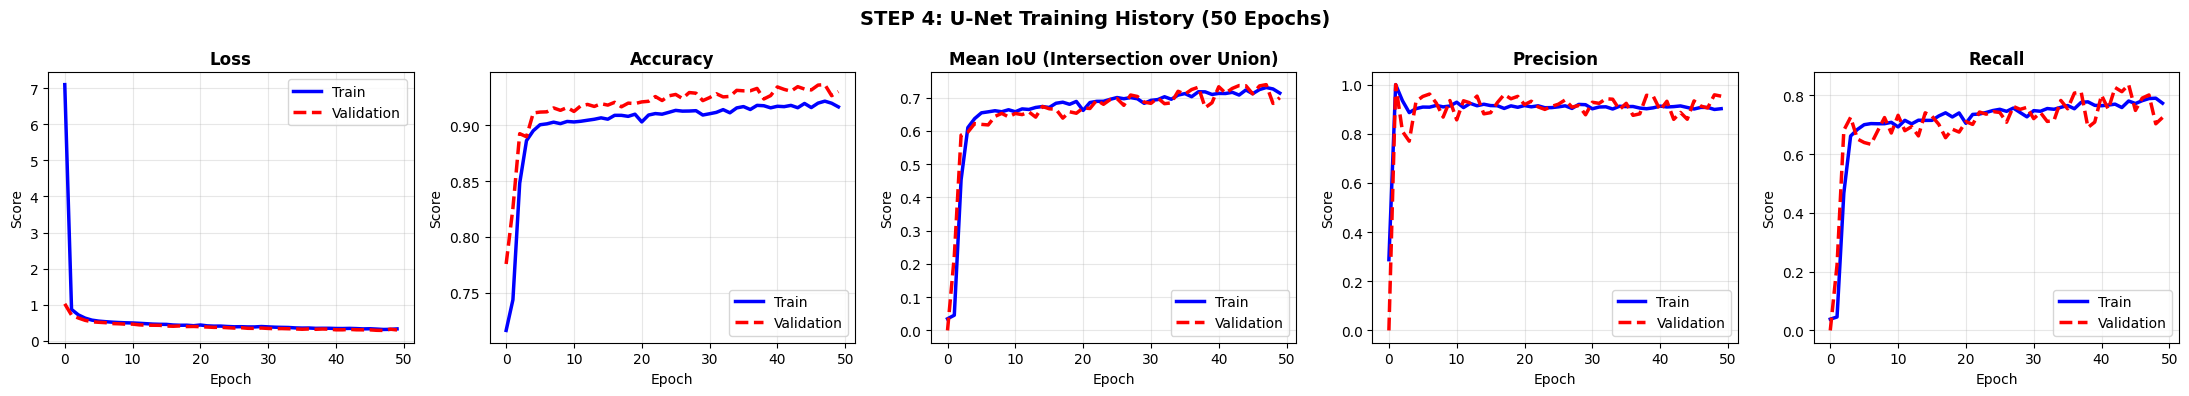

In [21]:
# Plot Training History
print("\n" + "=" * 70)
print("STEP 4 VISUALIZATION: Training Progression")
print("=" * 70)

metrics_to_plot = [
    ('loss',     'val_loss',     'Loss'),
    ('accuracy', 'val_accuracy', 'Accuracy'),
    ('iou',      'val_iou',      'Mean IoU (Intersection over Union)'),
    ('precision','val_precision','Precision'),
    ('recall',   'val_recall',   'Recall'),
]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(22, 4))
fig.suptitle('STEP 4: U-Net Training History (50 Epochs)', fontsize=14, fontweight='bold')

for ax, (train_key, val_key, title) in zip(axes, metrics_to_plot):
    if train_key in history.history:
        ax.plot(history.history[train_key],   label='Train', linewidth=2.5, color='blue')
        ax.plot(history.history[val_key],     label='Validation', linewidth=2.5, linestyle='--', color='red')
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Score')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step4_training_history.png', dpi=150, bbox_inches='tight')
plt.show()


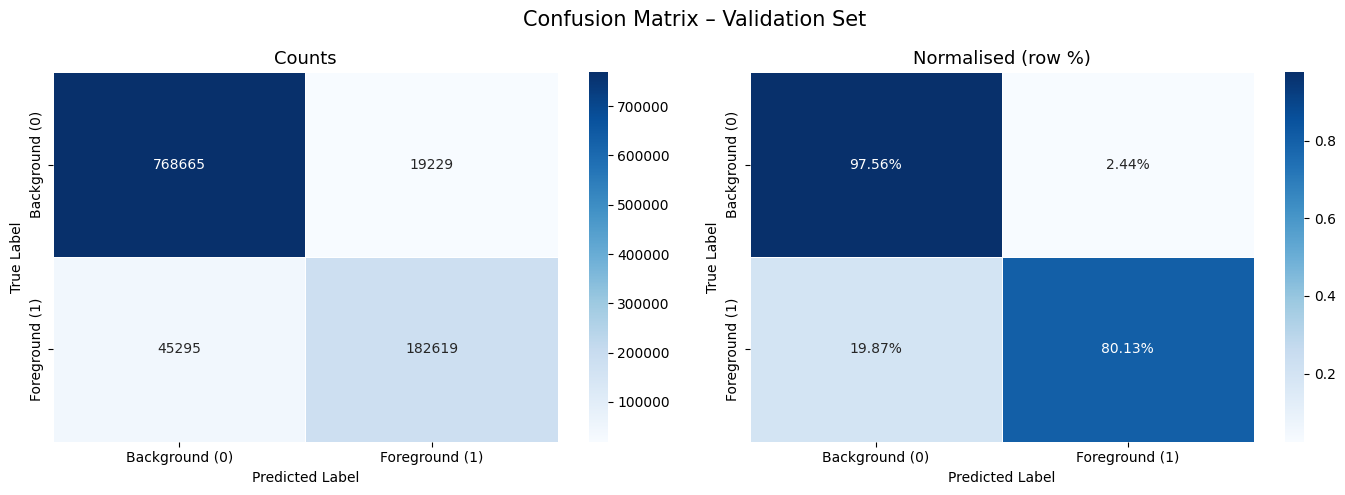


Classification Report:
              precision    recall  f1-score   support

  Background       0.94      0.98      0.96    787894
  Foreground       0.90      0.80      0.85    227914

    accuracy                           0.94   1015808
   macro avg       0.92      0.89      0.90   1015808
weighted avg       0.94      0.94      0.94   1015808

Saved confusion_matrix.png


In [22]:
# ── Confusion Matrix on Validation Set ───────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report

y_true_all, y_pred_all = [], []

for x_batch, y_batch in val_dataset:
    preds = model.predict(x_batch, verbose=0)          # (B, H, W, 1)  in [0,1]
    preds_bin = (preds > 0.5).astype(int).flatten()    # threshold → 0/1
    y_true_all.extend(y_batch.numpy().astype(int).flatten())
    y_pred_all.extend(preds_bin)

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

cm = confusion_matrix(y_true_all, y_pred_all)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix – Validation Set', fontsize=15)

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2%'],
    ['Counts', 'Normalised (row %)'],
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=['Background (0)', 'Foreground (1)'],
        yticklabels=['Background (0)', 'Foreground (1)'],
        linewidths=0.5, ax=ax
    )
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y_true_all, y_pred_all,
                             target_names=['Background', 'Foreground']))
print('Saved confusion_matrix.png')


# **Visualization image, label, prediction**

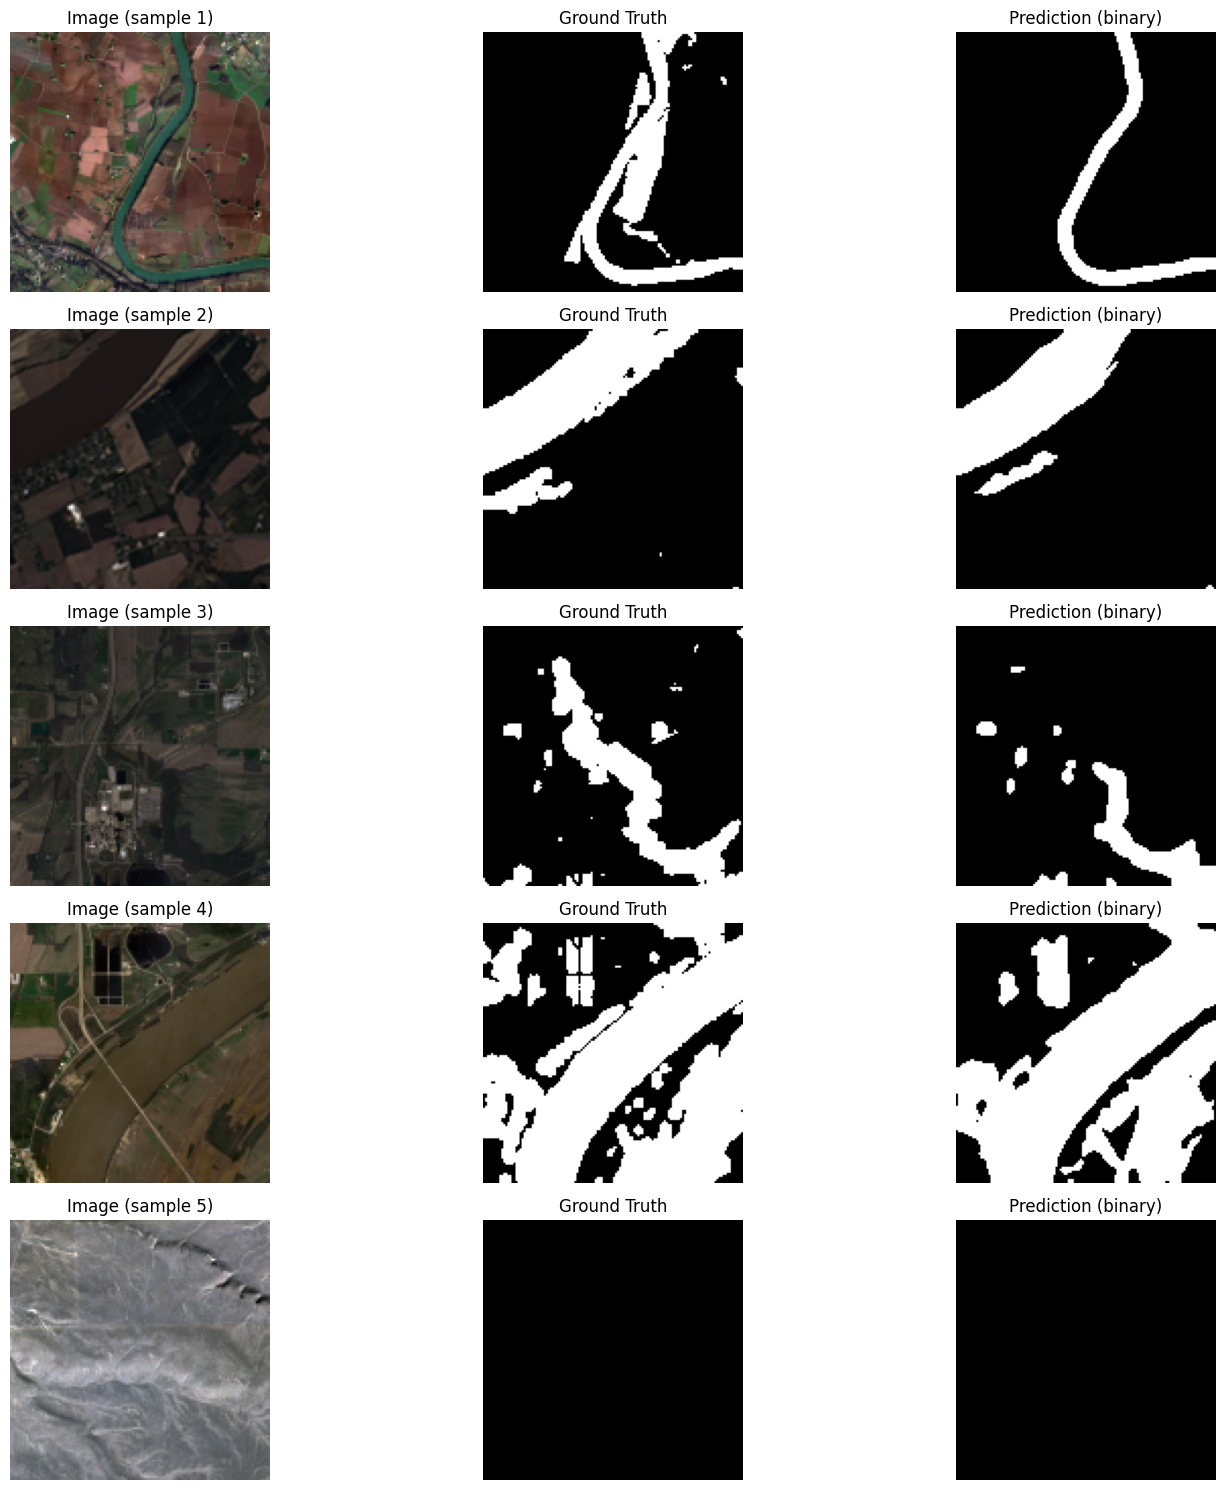

In [29]:
n_samples = 5
xs, ys = [], []
# Collect up to n_samples from val_dataset (handles batches)
for x_batch, y_batch in val_dataset:
    for i in range(x_batch.shape[0]):
        xs.append(x_batch[i].numpy())
        ys.append(y_batch[i].numpy())
        if len(xs) >= n_samples:
            break
    if len(xs) >= n_samples:
        break

if len(xs) == 0:
    raise RuntimeError('No samples found in val_dataset to visualize')

xs = xs[:n_samples]
ys = ys[:n_samples]
# Predict for all collected samples at once
preds = model.predict(np.stack(xs), verbose=0)  # (N, H, W, 1)
preds = np.squeeze(preds, axis=-1)  # (N, H, W)

fig, axes = plt.subplots(n_samples, 3, figsize=(16, 3 * n_samples))
if n_samples == 1:
    axes = axes[None, :]

for i in range(len(xs)):
    x = xs[i]
    y = ys[i].squeeze()
    pred = preds[i]

    # Build RGB using bands 4,3,2 if available (indexes 3,2,1)
    try:
        rgb = np.stack([x[:, :, 3], x[:, :, 2], x[:, :, 1]], axis=-1)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    except Exception:
        rgb = x[:, :, 0]

    ax = axes[i, 0]
    ax.imshow(rgb)
    ax.set_title(f'Image (sample {i+1})')
    ax.axis('off')

    ax = axes[i, 1]
    ax.imshow(y, cmap='gray')
    ax.set_title('Ground Truth')
    ax.axis('off')

    # ax = axes[i, 2]
    # im = ax.imshow(pred, cmap='viridis')
    # ax.set_title('Prediction (prob)')
    # ax.axis('off')
    # plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[i, 2]
    ax.imshow(pred > 0.5, cmap='gray')
    ax.set_title('Prediction (binary)')
    ax.axis('off')

plt.tight_layout()
plt.savefig('example_predictions_5.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
model.save("Water_Segmentation.keras")